# **Week 6 Assessment**

# Denoising Autoencoder using MNIST

## Objective
Build a Deep Learning model that removes noise from handwritten digit images using a Denoising Autoencoder.

### Steps
- Load and preprocess the MNIST dataset
- Add Gaussian noise to images
- Build and train a Denoising Autoencoder
- Reconstruct clean images from noisy inputs
- Compare original, noisy, and reconstructed images

# **Import Libraries**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

# **Load and Preprocess MNIST Dataset**

In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Training Images:", len(train_dataset))
print("Testing Images :", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.6MB/s]

Training Images: 60000
Testing Images : 10000


# **Create DataLoaders**

In [5]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Add Gaussian Noise

In [6]:
def add_noise(images, noise_factor=0.4):

    noise = torch.randn_like(images)

    noisy_images = images + noise_factor * noise

    noisy_images = torch.clamp(noisy_images, 0., 1.)

    return noisy_images

# Display Original and Noisy Images

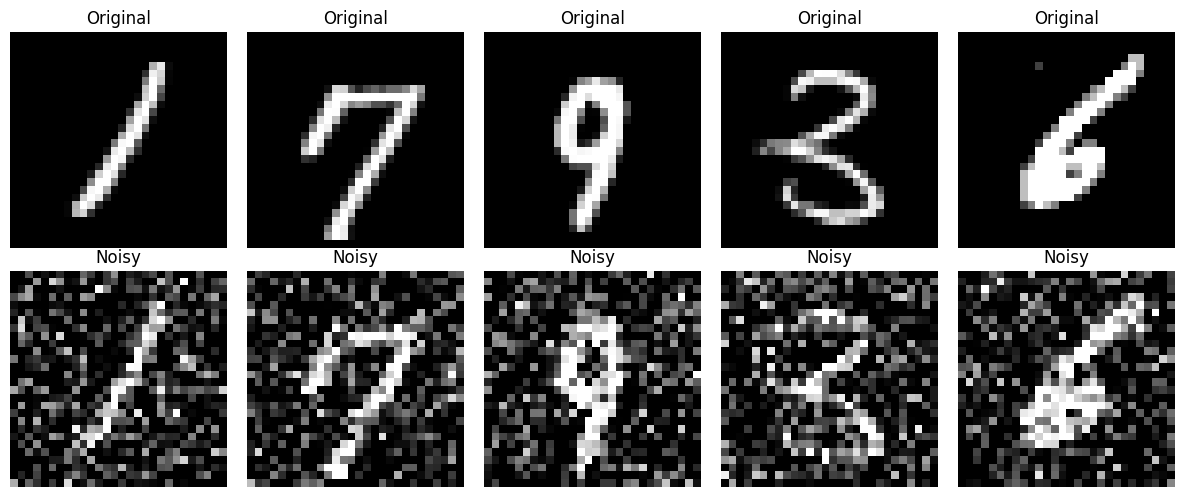

In [7]:
images, labels = next(iter(train_loader))

noisy_images = add_noise(images)

plt.figure(figsize=(12,5))

for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(noisy_images[i].squeeze(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Define the Denoising Autoencoder

In [8]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(16, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Create the Model

In [9]:
model = DenoisingAutoencoder().to(device)

print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


# Define Loss Function and Optimizer

In [10]:
criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Train the Model

In [11]:
# Number of training epochs
num_epochs = 20

# List to store training loss
train_losses = []


for epoch in range(num_epochs):

    model.train()
    running_loss = 0.0

    for images, _ in train_loader:


        images = images.to(device)


        noisy_images = add_noise(images).to(device)


        outputs = model(noisy_images)


        loss = criterion(outputs, images)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {epoch_loss:.4f}")

Epoch [1/20]  Loss: 0.0310
Epoch [2/20]  Loss: 0.0131
Epoch [3/20]  Loss: 0.0121
Epoch [4/20]  Loss: 0.0116
Epoch [5/20]  Loss: 0.0113
Epoch [6/20]  Loss: 0.0111
Epoch [7/20]  Loss: 0.0109
Epoch [8/20]  Loss: 0.0108
Epoch [9/20]  Loss: 0.0107
Epoch [10/20]  Loss: 0.0107
Epoch [11/20]  Loss: 0.0106
Epoch [12/20]  Loss: 0.0105
Epoch [13/20]  Loss: 0.0105
Epoch [14/20]  Loss: 0.0104
Epoch [15/20]  Loss: 0.0104
Epoch [16/20]  Loss: 0.0103
Epoch [17/20]  Loss: 0.0103
Epoch [18/20]  Loss: 0.0103
Epoch [19/20]  Loss: 0.0102
Epoch [20/20]  Loss: 0.0102


# Plot Training Loss

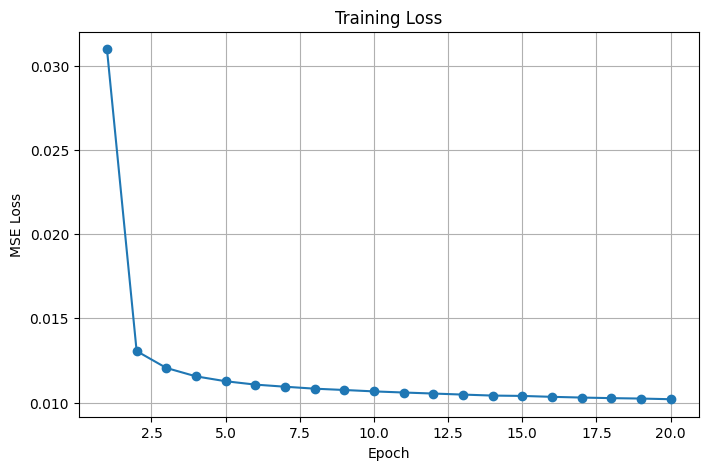

In [12]:
plt.figure(figsize=(8,5))

plt.plot(range(1, num_epochs + 1), train_losses, marker='o')

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)

plt.show()

# Save the Trained Model

In [13]:
torch.save(model.state_dict(), "denoising_autoencoder.pth")

print("Model saved successfully!")

Model saved successfully!


# Test the Model

In [18]:
# Set model to evaluation mode
model.eval()


images, _ = next(iter(test_loader))


images = images.to(device)


noisy_images = add_noise(images)


with torch.no_grad():
    reconstructed_images = model(noisy_images)

# Display Original, Noisy and Reconstructed Images

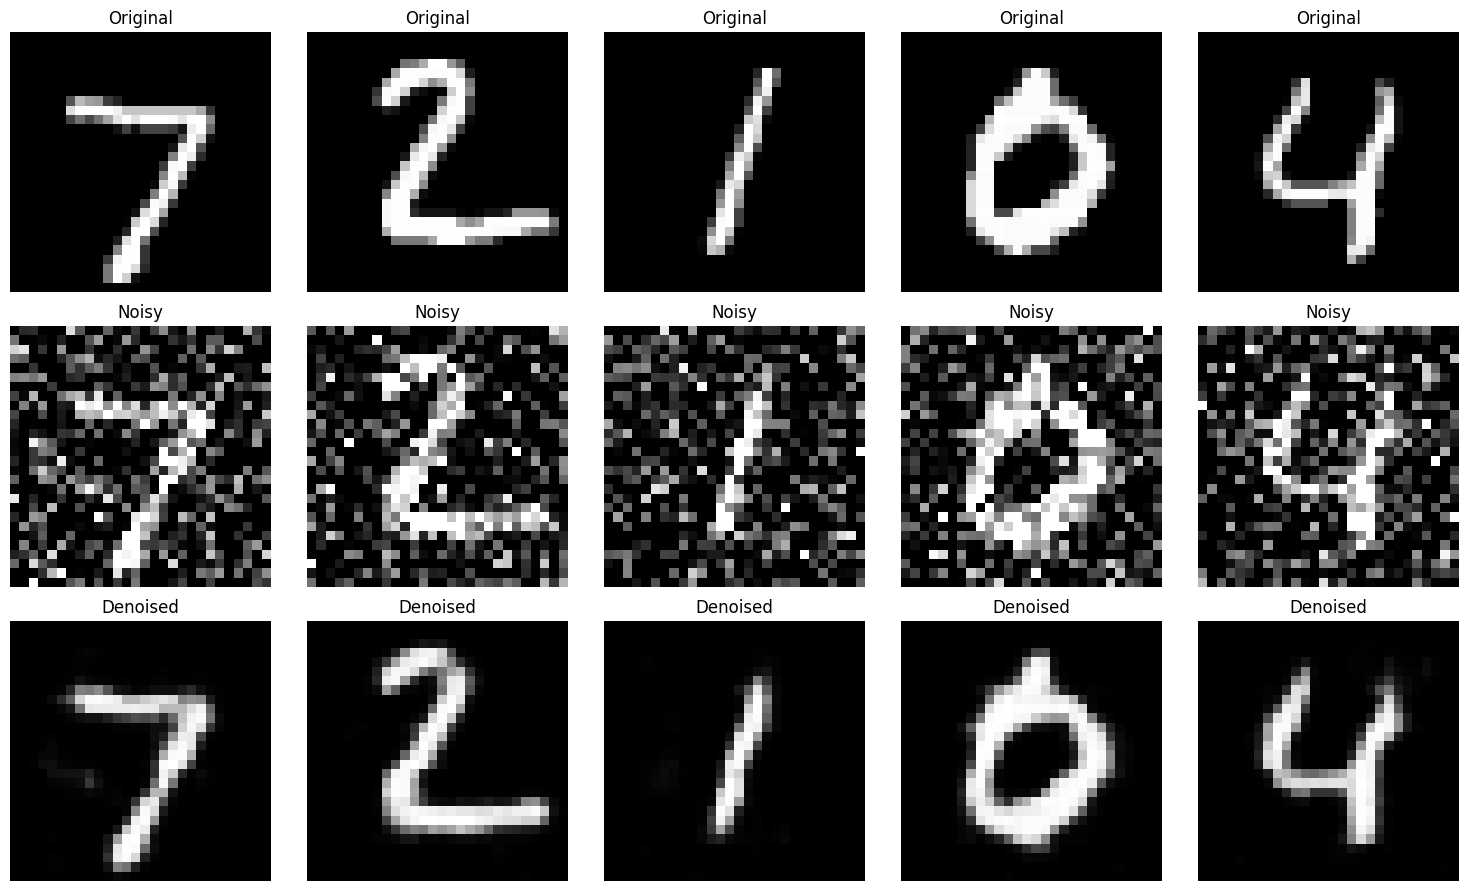

In [19]:

images = images.cpu()
noisy_images = noisy_images.cpu()
reconstructed_images = reconstructed_images.cpu()

plt.figure(figsize=(15,9))

for i in range(5):

    # Original Images
    plt.subplot(3,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Images
    plt.subplot(3,5,i+6)
    plt.imshow(noisy_images[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Reconstructed Images
    plt.subplot(3,5,i+11)
    plt.imshow(reconstructed_images[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Observations

- The Denoising Autoencoder successfully learned to reconstruct clean digit images from noisy inputs.
- The reconstructed images retained the overall digit shape while removing most of the Gaussian noise.
- The training loss decreased steadily, indicating effective learning.
- Some fine details may be slightly blurred because the model focuses on minimizing reconstruction error.
- Increasing the noise level makes the reconstruction task more challenging.

# Different Noise levels to compare performance

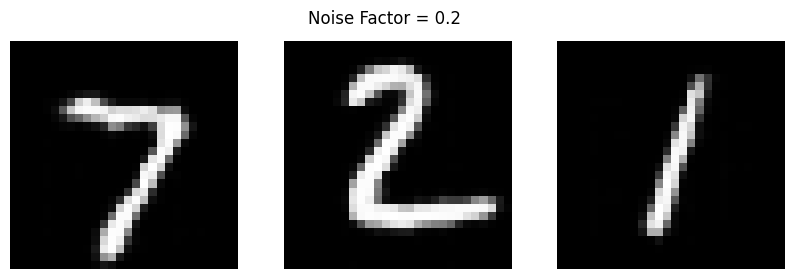

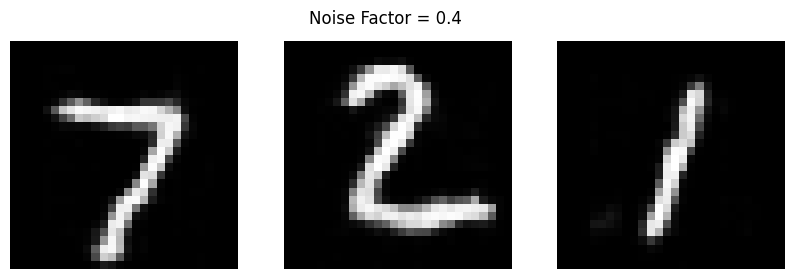

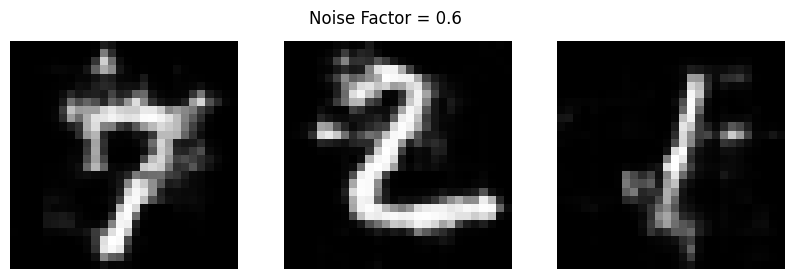

In [20]:
noise_levels = [0.2, 0.4, 0.6]

for level in noise_levels:
    noisy = add_noise(images, noise_factor=level)

    with torch.no_grad():
        denoised = model(noisy.to(device)).cpu()

    plt.figure(figsize=(10,3))

    plt.suptitle(f"Noise Factor = {level}")

    for i in range(3):
        plt.subplot(1,3,i+1)
        plt.imshow(denoised[i].squeeze(), cmap="gray")
        plt.axis("off")

    plt.show()